# Домашня робота 1 — Ітеративний прунінг VGG11 на CIFAR-10

**Курс:** Efficient ML, SET University

Ми навчаємо VGG11 на CIFAR-10, а потім прибираємо близько 80% ваг так, щоб
точність просіла якомога менше. Порівнюємо one-shot проти ітеративного прунінгу,
а в бонусній частині розбираємо, як саме розподіляти прунінг по шарах — і на
дрібнозернистому, і на структурному (канальному) рівні.

**Методологія оцінювання.** Тестовий набір ми чіпаємо рівно один раз для кожної
фінальної моделі — після того, як усі рішення вже прийнято. Усі проміжні числа,
криві та порівняння методів рахуються на валідації. Це принципово: інакше вибір
за тестом — це витік інформації.

### Підсумок

| Модель | Розрідженість | Точність (тест) |
|---|---|---|
| Baseline (щільна) | 0% | **90.71%** |
| One-shot 80% (після fine-tuning) | 80% | 90.72% |
| Ітеративний 80% (global magnitude) | 80.00% | **90.79%** |
| Бонус @95%: uniform-per-layer | 95% | 88.13% |
| Бонус @95%: sensitivity-guided | 95% | **89.94%** |

На 95% розрідженості sensitivity-guided випереджає наївний uniform на
+1.81 п.п. (тест) — саме там аналіз чутливості починає працювати.

## 1. Підготовка

In [1]:
import json
import torch
import matplotlib.pyplot as plt

from src.utils import set_seed, get_device
from src.data import build_loaders, CIFAR_MEAN, CIFAR_STD
from src.model import build_vgg11_cifar, count_parameters
from src import prune, plots

RESULTS = "results"
set_seed(42)
device = get_device()
print("device:", device, "| torch:", torch.__version__)

device: cuda | torch: 2.11.0+cu130


## 2. Дані: CIFAR-10

60 000 кольорових зображень 32×32 у 10 класах. Стандартний поділ — 50 000 на
навчання і 10 000 на тест. Від навчальної частини відрізаємо 5 000 на валідацію:
за нею відбираємо найкращу модель і робимо всі порівняння, а тестові 10 000
залишаємо на самий кінець. Аугментації для навчання — випадковий зсув
(`RandomCrop` з відступом 4) і горизонтальне віддзеркалення.

/home/deploy/efficientml/venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


train=45000  val=5000  test=10000


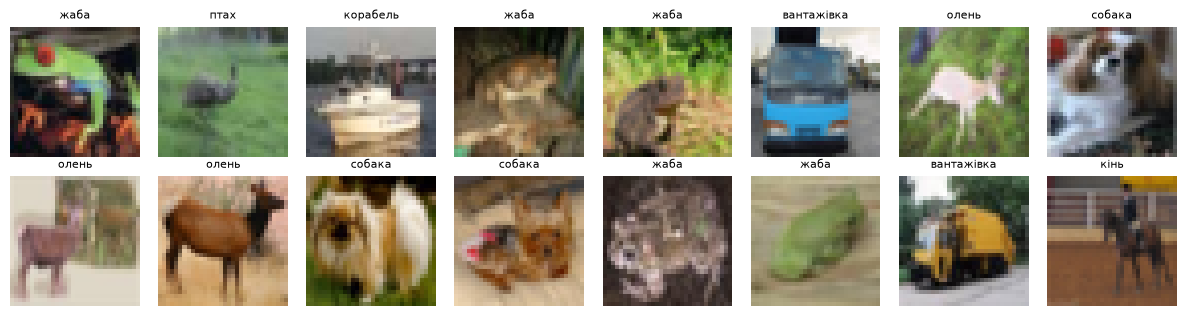

In [2]:
train_loader, val_loader, test_loader = build_loaders("./data", batch_size=256)
print(f"train={len(train_loader.dataset)}  val={len(val_loader.dataset)}  test={len(test_loader.dataset)}")

import torch
classes = ['літак','авто','птах','кіт','олень','собака','жаба','кінь','корабель','вантажівка']
mean = torch.tensor(CIFAR_MEAN).view(3,1,1); std = torch.tensor(CIFAR_STD).view(3,1,1)
imgs, labels = next(iter(val_loader))
fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for ax, img, lbl in zip(axes.flat, imgs, labels):
    ax.imshow((img*std+mean).clamp(0,1).permute(1,2,0).numpy())
    ax.set_title(classes[lbl], fontsize=8); ax.axis('off')
plt.tight_layout(); plt.show()

## 3. Модель: VGG11 з torchvision, адаптована під CIFAR

Беремо `vgg11_bn` з torchvision. Оригінал розрахований на ImageNet (вхід 224×224):
після п'яти пулінгів лишається карта 7×7, а класифікатор — три величезні
повнозв'язні шари (~124 млн параметрів). Наш вхід 32×32 стискається до 1×1, тому
ImageNet-голова недоречна. Згортковий кістяк VGG11 лишаємо без змін, а голову
замінюємо на компактну під 10 класів. Версію з batch-norm обрано свідомо: без неї
VGG11 з нуля на CIFAR навчається нестабільно.

In [3]:
model = build_vgg11_cifar().to(device)
print(f"Параметрів: {count_parameters(model)/1e6:.2f}M")
print(model.classifier)

Параметрів: 9.49M
Sequential(
  (0): Linear(in_features=512, out_features=512, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=512, out_features=10, bias=True)
)


### Як обрізаємо ваги (дрібнозернистий прунінг)

Обнуляємо ваги, найменші за модулем, у кожному згортковому й повнозв'язному шарі.
Маска запам'ятовується і накладається після кожного кроку оптимізатора — обнулені
ваги лишаються нулем, решта продовжує вчитися.

In [4]:
import inspect
from src.prune import _layer_mask, FineGrainedPruner
print(inspect.getsource(_layer_mask))
print(inspect.getsource(FineGrainedPruner.apply))

def _layer_mask(weight: torch.Tensor, sparsity: float) -> torch.Tensor:
    """Keep the (1 - sparsity) fraction of weights with the largest magnitude."""
    if sparsity <= 0:
        return torch.ones_like(weight)
    n = weight.numel()
    k = int(round(sparsity * n))  # number of weights to zero out
    if k <= 0:
        return torch.ones_like(weight)
    if k >= n:
        return torch.zeros_like(weight)
    threshold = torch.kthvalue(weight.abs().flatten(), k).values
    return (weight.abs() > threshold).float()

    @torch.no_grad()
    def apply(self, model):
        layers = dict(prunable_layers(model))
        for name, mask in self.masks.items():
            w = layers[name].weight
            w.data.mul_(mask.to(w.device))



## 4. Baseline

80 епох SGD (momentum 0.9, Nesterov, weight decay 5e-4) з косинусним спадом.
Відбираємо ваги за найкращою валідацією (91.56%) і лише тоді міряємо
тест: **90.71%**. Це відправна точка для всіх обрізаних моделей.

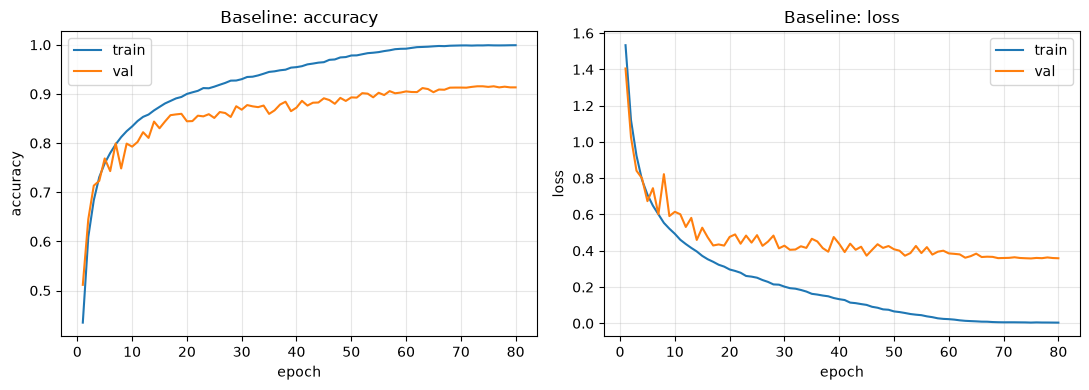

val = 91.56%   TEST = 90.71%


In [5]:
base = json.load(open(f"{RESULTS}/baseline.json"))
plots.plot_history(base["history"], "Baseline"); plt.show()
print(f"val = {base['val']*100:.2f}%   TEST = {base['test']*100:.2f}%")

## 5. One-shot прунінг: зрізаємо 80% за один раз

Найпростіший підхід — одразу обнулити 80% ваг за глобальним порогом і до-навчити.
Одразу після зрізу валідаційна точність падає до **63.28%** (модель
фактично зламана), але кілька епох до-навчання відновлюють її майже до рівня
baseline. Фінальний тест одношотної моделі — **90.72%**.

In [6]:
os_ = json.load(open(f"{RESULTS}/oneshot.json"))
print(f"sparsity            = {os_['sparsity']*100:.1f}%")
print(f"val ДО до-навчання  = {os_['val_before_ft']*100:.2f}%")
print(f"val ПІСЛЯ           = {os_['val']*100:.2f}%")
print(f"TEST (фінально)     = {os_['test']*100:.2f}%")

sparsity            = 80.0%
val ДО до-навчання  = 63.28%
val ПІСЛЯ           = 91.74%
TEST (фінально)     = 90.72%


## 6. Ітеративний прунінг: доходимо до 80% поступово

Замість різкого зрізу нарощуємо розрідженість за кілька кроків, до-навчаючи між
ними. Розклад [0.2752, 0.4747, 0.6193, 0.7241, 0.8] прибирає однакову частку ваг, що ще
лишились, і на останньому кроці виходить рівно на 80%.

Криві нижче — на **валідації**. Помітно, як «одразу після зрізу» модель
провалюється дедалі глибше, а «після до-навчання» тримається майже на рівні
baseline. Фінальний тест ітеративної моделі — **90.79%**.

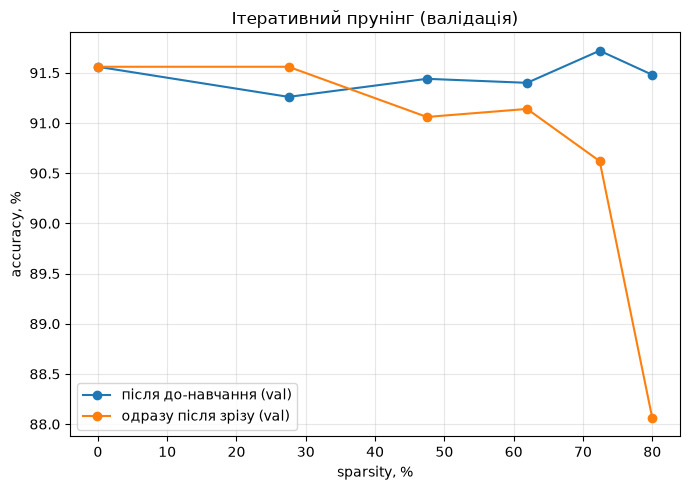

фінальний ітеративний TEST = 90.79%   (one-shot TEST = 90.72%)


In [7]:
it = json.load(open(f"{RESULTS}/iterative.json"))
plots.plot_sparsity_vs_acc({
    "після до-навчання (val)": it["val_points"],
    "одразу після зрізу (val)": [[0.0, base['val']]] + it["val_after_cut"],
}, "Ітеративний прунінг (валідація)"); plt.show()
print(f"фінальний ітеративний TEST = {it['test']*100:.2f}%   "
      f"(one-shot TEST = {it['oneshot_test']*100:.2f}%)")

На 80% ітеративний (90.79%) і one-shot (90.72%) виходять майже
однаково — на CIFAR-10 надлишкових ваг настільки багато, що навіть різкий зріз
відновлюється. Різниця в тому, *наскільки боляче* проходить сам зріз: one-shot
падає до 63.28%, ітеративний майже не помічає кожного окремого кроку.

## 7. Бонус, частина 1 — як розподіляти прунінг по шарах (дрібнозернистий)

Порівнюємо три способи задати, скільки різати в кожному шарі, при однаковій
сумарній розрідженості, через свіп по рівнях sparsity (усе на валідації):

- **uniform per-layer** — однаковий відсоток у кожному шарі (наївний);
- **global magnitude** — один глобальний поріг за модулем (наш основний метод);
- **sensitivity-guided** — per-layer бюджет за аналізом чутливості шарів.

Аналіз чутливості: по черзі обрізаємо лише один шар (без до-навчання) і дивимось,
де точність провалюється рано — такі шари чутливі, їх треба берегти.

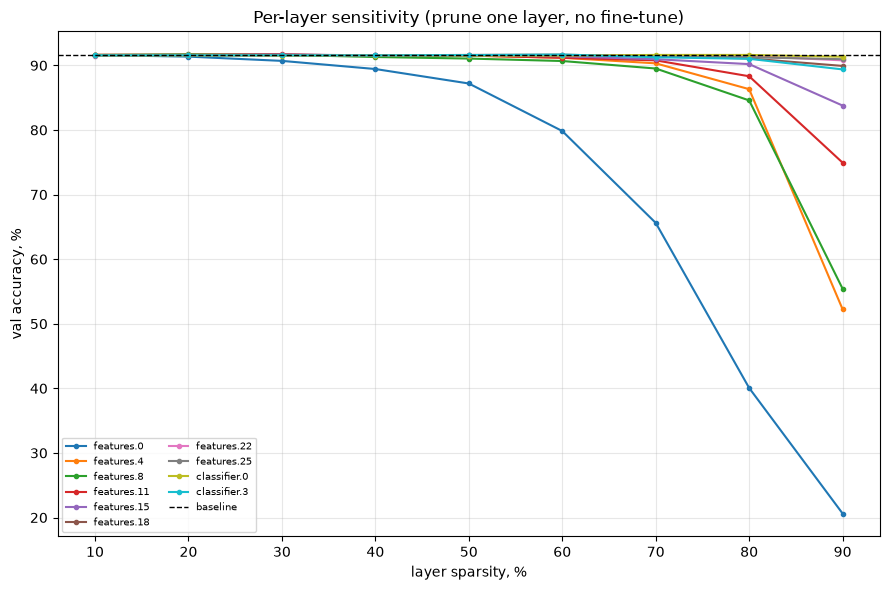

In [8]:
sens = json.load(open(f"{RESULTS}/sensitivity.json"))
plots.plot_sensitivity(sens["curves"], base["val"]); plt.show()

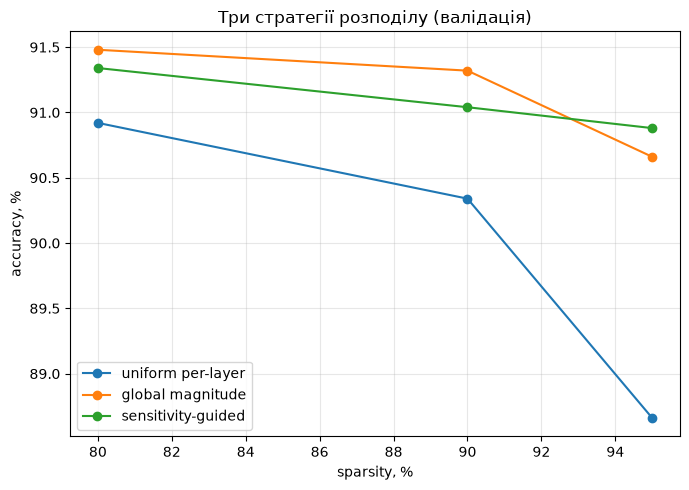

TEST на 80% (раз на модель):
  uniform per-layer   : 90.50% @ 80.0%
  global magnitude    : 90.79% @ 80.0%
  sensitivity-guided  : 90.22% @ 80.0%


In [9]:
labels = {"uniform_layer":"uniform per-layer","global":"global magnitude",
          "sensitivity":"sensitivity-guided"}
plots.plot_sparsity_vs_acc({labels[k]: sens["sweep"][k] for k in labels},
                           "Три стратегії розподілу (валідація)"); plt.show()
print("TEST на 80% (раз на модель):")
for k in labels:
    print(f"  {labels[k]:20s}: {sens['headline_test'][k]*100:.2f}% "
          f"@ {sens['headline_sparsity'][k]*100:.1f}%")

In [10]:
c = json.load(open(f"{RESULTS}/confirm95.json"))["results"]
print("TEST на 95% розрідженості (раз на модель):")
for k in ["uniform_layer","global","sensitivity"]:
    print(f"  {k:16s}: {c[k]['test']*100:.2f}%  @ {c[k]['sparsity']*100:.1f}%")

TEST на 95% розрідженості (раз на модель):
  uniform_layer   : 88.13%  @ 95.0%
  global          : 89.93%  @ 95.0%
  sensitivity     : 89.94%  @ 95.0%


**Висновок частини 1.** На 80–90% усі три методи в межах шуму, трохи попереду
global magnitude (90.79% на тесті на 80%). Але зі зростанням
розрідженості наївний uniform-per-layer валиться найшвидше, і на **95%**
sensitivity-guided його впевнено обганяє — на тесті **89.94% проти
88.13% (+1.81 п.п.)**, практично наздоганяючи global
(89.93%).

Чому так. Глобальний поріг за модулем прибирає саме глобально найменші ваги —
мінімальне збурення мережі, тому при помірній розрідженості його важко
перевершити. Але коли ваг лишається дуже мало, критично стає не чіпати чутливі
шари (перші згортки, класифікатор) — і тут аналіз чутливості дає перевагу. Тобто
цінність sensitivity зростає саме на агресивній розрідженості — і на тому самому
бюджеті ваг вона дає вищу точність, ніж наївний рівномірний прунінг.

## 8. Бонус, частина 2 — структурний (канальний) прунінг

Тут ми **фізично видаляємо цілі згорткові фільтри** (через `torch-pruning`), а не
обнуляємо окремі ваги. Це справжнє зменшення обчислень: на щільній моделі
154M MACs, після прунінгу — менше, і це прямо перетворюється
на швидший inference (те, що потрібно у фінальному проекті на Raspberry Pi).

Тут per-layer розподіл справді вирішує: у шарів різна форма й різна важливість
каналів, єдиного глобального критерію нема. Порівнюємо **uniform** проти
**sensitivity-guided** канального прунінгу на однаковому бюджеті MACs.

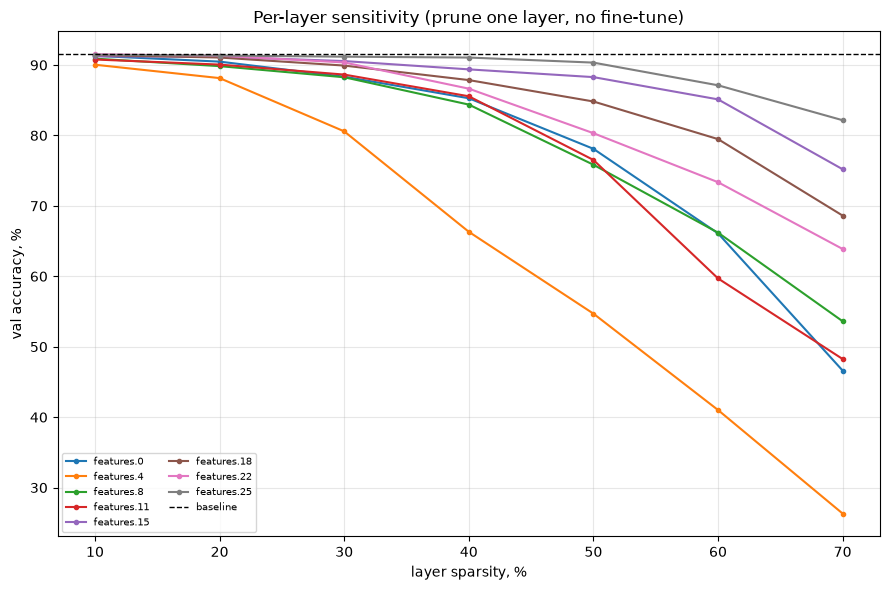

In [11]:
st = json.load(open(f"{RESULTS}/structured.json"))
plots.plot_sensitivity(st["curves"], st["base_val"]); plt.show()   # чутливість каналів

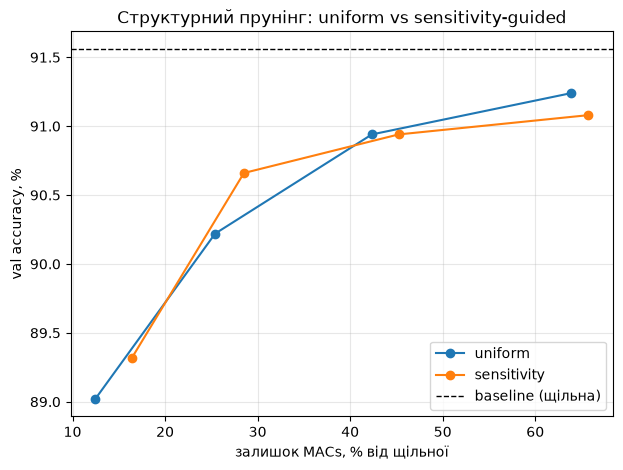

HEADLINE (~50% MACs, TEST раз на модель):
  uniform     : 90.40%  @ 42% MACs, 4.00M params
  sensitivity : 89.78%  @ 45% MACs, 3.45M params


In [12]:
fig, ax = plt.subplots(figsize=(7,5))
for method in ["uniform","sensitivity"]:
    pts = sorted(st["sweep"][method])
    ax.plot([p[0]*100 for p in pts], [p[1]*100 for p in pts], marker="o", label=method)
ax.axhline(st["base_val"]*100, color="k", ls="--", lw=1, label="baseline (щільна)")
ax.set_xlabel("залишок MACs, % від щільної"); ax.set_ylabel("val accuracy, %")
ax.set_title("Структурний прунінг: uniform vs sensitivity-guided")
ax.legend(); ax.grid(alpha=0.3); plt.show()

h = st["headline"]
print("HEADLINE (~50% MACs, TEST раз на модель):")
for m in ["uniform","sensitivity"]:
    print(f"  {m:12s}: {h[m]['test']*100:.2f}%  @ {h[m]['macs_frac']*100:.0f}% MACs, "
          f"{h[m]['params_M']:.2f}M params")

**Висновок частини 2.** Головне, що дає структурний прунінг — **реальне зменшення
обчислень**: щільна модель 154M MACs, а на ~42%
MACs вона ще тримає ~90.40% на тесті. Це саме те, що прискорює
inference на Raspberry Pi.

А от **наївний sensitivity тут не переграв uniform** (криві майже збігаються, на
~50% MACs навіть трохи гірше: 89.78% проти 90.40%).
Причина повчальна: розподіл, побудований лише за *точністю*, **сліпий до вартості
MACs**. Він береже чутливі ранні згортки (а вони найдорожчі за обчисленнями, бо
працюють на великій роздільній здатності) і сильніше ріже останній conv, який на
карті 1×1 майже безкоштовний. Тобто економить обчислення не там, де треба.

Правильний наступний крок — **MAC-aware розподіл** (різати сильніше там, де шар і
надлишковий, і дорогий за обчисленнями). Це напрям NetAdapt / AMC і прямий місток
до фінального проекту, де метрика — саме FPS, а не абстрактна розрідженість.

## 9. Звіт: висновки і рефлексія

**Що спрацювало добре.** Дрібнозернистий прунінг прибрав 80% ваг практично без
втрати точності — 90.71% → 90.79% (+0.08 п.п.),
у межах шуму. Ключове — до-навчання між зрізами. Бонусний результат: на **95%**
розрідженості аналіз чутливості дав вимірну перевагу над наївним рівномірним
прунінгом — 89.94% проти 88.13% на тесті
(+1.81 п.п.). Структурний прунінг показав реальне зменшення обчислень:
154M → ~65M MACs
при ~90.40%.

**Що вийшло не так, як очікувалось.** По-перше, при помірній розрідженості (80–90%)
аналіз чутливості **не перевершив global magnitude** (90.79%) — і це
не брак реалізації, а властивість дрібнозернистого прунінгу: глобальний поріг за
модулем уже майже оптимальний. По-друге, наївний sensitivity у структурному
прунінгу **не переграв uniform**, бо розподіл за самою лише точністю сліпий до
вартості MACs (береже дорогі ранні шари, ріже дешеві пізні). Обидва спостереження
уточнюють, *де саме* аналіз чутливості корисний: на агресивній розрідженості та за
MAC-aware розподілу.

**Чому результати можуть бути не ідеальними.** Дрібнозернистий прунінг не дає
реального прискорення на GPU (лише формальна розрідженість). Бюджети до-навчання
обмежені часом. Критерій за модулем жадібний і не враховує взаємодію ваг. Чутливість
зондується без до-навчання, тож недооцінює, наскільки шар відновлюється.

**Як можна покращити.** MAC-aware розподіл для структурного прунінгу (NetAdapt /
AMC) — різати там, де шар і надлишковий, і дорогий; довести структурний прунінг до
реального FPS на Raspberry Pi; більше епох до-навчання і кроків; зв'язка з
квантизацією та дистиляцією; критерії відбору з урахуванням градієнтів.

## 10. Відтворення

```bash
python run_all.py --data-dir ./data --out results        # baseline, one-shot, iterative, sweep
python run_structured.py --data-dir ./data --out results  # структурний бонус (реюзає baseline.pt)
python build_notebook.py results                          # зібрати цей ноутбук
```

Код у `src/`: `data.py`, `model.py`, `engine.py`, `prune.py` (дрібнозернистий),
`sensitivity.py`, `structured.py` (канальний, torch-pruning), `plots.py`.